# **Computing Scattering Data: Examples**

In [1]:
# Core
import scipy
import numpy as np
import matplotlib.pyplot as plt
from compute_scattering_data import scattering_data, scattering_data_sequence, IST_reflectionless

rng = np.random.RandomState(42)

In [2]:
# Plot settings
import matplotlib

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100
#plt.rcParams['figure.dpi'] = 300

matplotlib.rc('xtick', labelsize=10, direction='out')
matplotlib.rc('ytick', labelsize=10, direction='out')

#### **SINGLE SNAPSHOT OF SOLITON DATA**

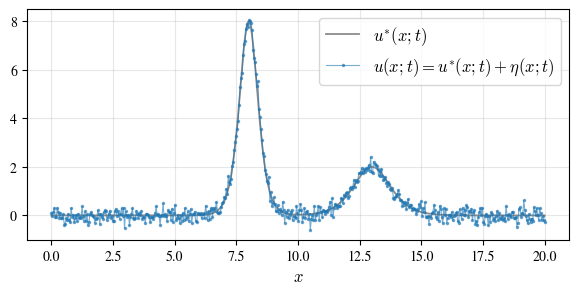

In [3]:
# Example noisy data
Nx = 500
a,b = 0,20
x = np.linspace(a,b,Nx)
dx = x[1] - x[0]

# Use them fancy exact solitons
kdv_soliton = lambda kappa,x0: 2*kappa**2*(1/np.cosh(kappa*(x-x0)))**2
sigma = 0.2

kappa_true, x0_true = 2,8
u_star = kdv_soliton(kappa_true,x0_true)
u_star += kdv_soliton(1,13)
u = u_star + rng.normal(0, sigma, Nx)

# Plot that pup
plt.figure(figsize=(7,3))
plt.plot(x, u_star, '-', color='grey', lw=1.3, alpha=0.9, label=r'$u^{*}(x;t)$')
plt.plot(x, u, '.-', color='C0', lw=0.8, ms=3, alpha=0.6, label=r'$u(x;t) = u^{*}(x;t) + \eta(x;t)$')
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.xlabel(r'$x$')
plt.show()

Compute Lax operator: $$\begin{align*}
    \mathbf{L} = -(\mathbf{D}_{xx} + \mathbf{U}) = \mathbf{Q \Lambda Q}^T
\end{align*}$$

In [4]:
data = scattering_data(x, u, auto_compute=False)
data_star = scattering_data(x, u_star, auto_compute=False)

# Lax operator
L = data.L
L_star = data_star.L

# Eigen-decomp
Lambda, Q = data.compute_eigen_decomp()
Lambda_star, Q_star = data_star.compute_eigen_decomp()

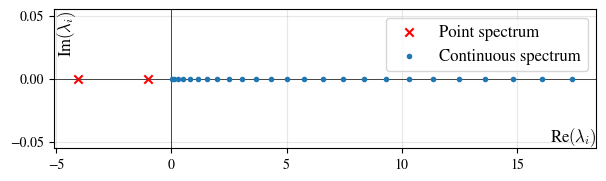

In [5]:
# Plot the spectrum
data.compute_spectrum()
n = data.n
point_spectrum = data.point_spectrum
continuous_spectrum = data.continuous_spectrum[:25]

plt.figure(figsize=(7,1.8))
plt.axhline(0, color='black', lw=0.7, alpha=0.7)
plt.axvline(0, color='black', lw=0.7, alpha=0.7)
plt.scatter(point_spectrum.real, point_spectrum.imag, color='red', marker='x', label='Point spectrum', zorder=10)
plt.scatter(continuous_spectrum.real, continuous_spectrum.imag, color='C0', marker='.', label='Continuous spectrum', zorder=10)
plt.xlabel(r'Re$(\lambda_i)$', loc='right', labelpad=-33)
plt.ylabel(r'Im$(\lambda_i)$', loc='top', labelpad=-49)
plt.grid(True, linestyle='-', alpha=0.3)
plt.legend()
plt.show()

Compute $\kappa_i = \sqrt{-\lambda_i},$ for $i = 1, \dots, n$

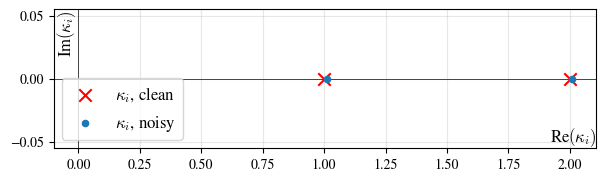

In [6]:
kappas = data.compute_kappas()
kappas_star = data_star.compute_kappas()

# Compare real vs noisy
plt.figure(figsize=(7,1.8))
plt.axhline(0, color='black', lw=0.7, alpha=0.7)
plt.axvline(0, color='black', lw=0.7, alpha=0.7)
plt.scatter(kappas_star.real, kappas_star.imag, color='red', marker='x', s=80, label=r'$\kappa_i$, clean', zorder=10)
plt.scatter(kappas.real, kappas.imag, color='C0', marker='.', s=80, label=r'$\kappa_i$, noisy', zorder=10)
plt.xlabel(r'Re$(\kappa_i)$', loc='right', labelpad=-33)
plt.ylabel(r'Im$(\kappa_i)$', loc='top', labelpad=-49)
plt.grid(True, linestyle='-', alpha=0.3)
plt.legend(loc='lower left')
plt.show()

Positive Jost solution: $$\begin{align*}
    \begin{cases}
        \phi_{+}(x;k) \sim e^{ikx} = e^{-\kappa x},
        \\
        \phi_{+}'(x;k) \sim ike^{ikx} = -\kappa e^{-\kappa x},
    \end{cases}
    \ \ \ \text{as} \quad x \rightarrow +\infty.
\end{align*}$$ Define $\psi(x;k) := e^{-ikx}\phi_+(x;k) = e^{\kappa x}\phi_+(x;i\kappa)$ and note that $$\begin{align*}
    \begin{cases}
        \psi = e^{\kappa x}\phi_{+} \sim 1,
        \\
        \psi' = e^{\kappa x}\phi_{+}' + \kappa e^{\kappa x}\phi_{+} \sim 0,
    \end{cases}
    \ \ \ \text{as} \quad x \rightarrow +\infty.
\end{align*}$$ Substitute into $L\phi_+ = k^2\phi_+$ on $x \in [a,b]$ at $k_i = i\kappa_i$ to get $$\begin{align*}
    \boxed{-\psi'' + 2\kappa_i\psi' - u(x;t)\psi = 0,
    \quad \text{for} \quad
    \begin{cases}
        x \in [a,b],
        \\
        \psi(b) = 1,
        \\
        \psi'(b) = 0.
    \end{cases}}
\end{align*}$$ Compute norming constants $$\begin{align*}
    c(\kappa_i) := \left[ \int_{a}^{b} e^{-2\kappa_ix} \psi(x;i\kappa_i)^2 \, dx \right]^{-1}\!\!,
\end{align*}$$ or equivalently, $$\begin{align*}
    \boxed{\log c(\kappa_i) = - \log\left(\int_{a}^{b} e^{-2\kappa_ix} \psi(x;i\kappa_i)^2 \, dx \right).}
\end{align*}$$

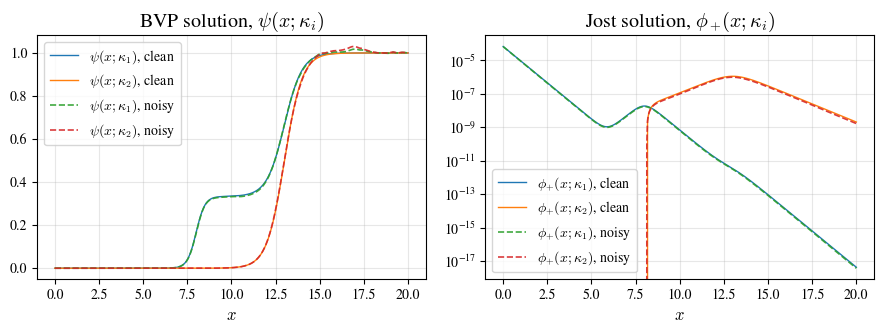

In [7]:
# Noisy data and clean data
jost_fcns = data.solve_jost_bvps()
jost_fcns_star = data_star.solve_jost_bvps()

# Print zis puppy
fig, axes = plt.subplots(1, 2, figsize=(9,3.5), sharex=True)

for i,fcn in enumerate(jost_fcns_star, start=1):
    axes[0].plot(x, fcn["psi"], lw=1.0, label=rf"$\psi(x;\kappa_{i})$, clean")
    axes[1].plot(x, fcn["phi_plus"], lw=1.0, label=rf"$\phi_{{+}}(x;\kappa_{i})$, clean")

for i,fcn in enumerate(jost_fcns, start=1):
    axes[0].plot(x, fcn["psi"], "--", lw=1.2, alpha=0.9, label=rf"$\psi(x;\kappa_{i})$, noisy")
    axes[1].plot(x, fcn["phi_plus"], "--", lw=1.2, alpha=0.9, label=rf"$\phi_{{+}}(x;\kappa_{i})$, noisy")

axes[0].set_title(r"BVP solution, $\psi(x;\kappa_{i})$")
axes[0].set_xlabel(r"$x$")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

axes[1].set_title(r"Jost solution, $\phi_+\!(x;\kappa_{i})$")
axes[1].set_xlabel(r"$x$")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

Noisy norming constants
i=1: kappa=2.0072, integral=3.0211e-16, log c=35.7358, c=3.3101e+15
i=2: kappa=1.0104, integral=1.9693e-12, log c=26.9533, c=5.0779e+11

Clean norming constants
i=1: kappa=2.0004, integral=3.5062e-16, log c=35.5868, c=2.8521e+15
i=2: kappa=1.0000, integral=2.5533e-12, log c=26.6936, c=3.9165e+11


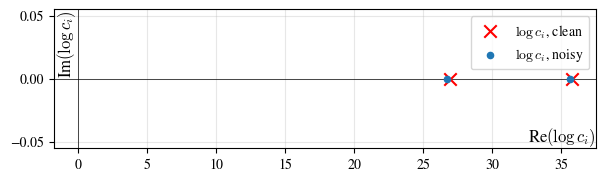

In [8]:
norming_constants = data.compute_norming_constants()
norming_constants_star = data_star.compute_norming_constants()

# Noisy version
kappas = norming_constants["kappa"]
weighted_norms = norming_constants["weighted_norm"]
log_cs = norming_constants["log_c"]
cs = norming_constants["c"]

# Clean version
kappas_star = norming_constants_star["kappa"]
weighted_norms_star = norming_constants_star["weighted_norm"]
log_cs_star = norming_constants_star["log_c"]
cs_star = norming_constants_star["c"]

# Compare real vs noisy
data.print_norming_constants("Noisy norming constants")
data_star.print_norming_constants("\nClean norming constants")

plt.figure(figsize=(7,1.8))
plt.axhline(0, color='black', lw=0.7, alpha=0.7)
plt.axvline(0, color='black', lw=0.7, alpha=0.7)
plt.scatter(log_cs.real, log_cs.imag, color='red', marker='x', s=80, label=r'$\log c_i$, clean', zorder=10)
plt.scatter(log_cs_star.real, log_cs_star.imag, color='C0', marker='.', s=80, label=r'$\log c_i$, noisy', zorder=10)
plt.xlabel(r'Re$(\log c_i)$', loc='right', labelpad=-33)
plt.ylabel(r'Im$(\log c_i)$', loc='top', labelpad=-49)
plt.grid(True, linestyle='-', alpha=0.3)
plt.legend(loc='upper right', fontsize=10)
plt.show()

Reconstruct solution via the GLM equation: $$\begin{align*}
    u(x) = 2 \frac{d}{dx} K(x,x),
    \quad \text{where} \quad
    K(x,y;t) \, + \, G_{\!\sigma}(x+y;t) \, + \int_x^{\infty} K(x,s;t) \, G_{\!\sigma}(s + y; t) \, ds = 0,
    \quad \text{for} \quad
    y \geq x.
\end{align*}$$ Here, the function $G_{\!\sigma}$ denotes the observed reflection response and is defined by $$\begin{align*}
    G_{\!\sigma}(x) = \sum_{i=1}^{n} c_i e^{-\kappa_ix} \, + \, \underbrace{\frac{1}{2\pi} \int_{-\infty}^{\infty} R(k) e^{ikx} dk}_{\text{$=0$ for pure solitons}}.
\end{align*}$$ For the **reflectionless** (i.e., pure soliton) **case**, can also just compute $$\begin{align*}
    u(x) = 2 \frac{d^2}{dx^2} \log|\mathbf{A}(x)|,
    \quad \text{where} \quad
    \mathbf{A}_{ij}(x) := \delta_{ij} + \frac{\sqrt{c_ic_j} e^{-(\kappa_i + \kappa_j)x}}{\kappa_i + \kappa_j},
\end{align*}$$ or equivalently, $$\begin{align*}
    \boxed{u(x) = 4 \mathbf{y}^T\mathbf{A}^{-1}(x)\mathbf{z} -2 \big(\mathbf{z}^T\mathbf{A}^{-1}(x)\mathbf{z}\big)^2,
    \quad \text{where} \quad
    \begin{cases}
        z_i := \sqrt{c_i} e^{-\kappa_ix},
        \\
        y_i := \kappa_iz_i.
    \end{cases}}
\end{align*}$$

Relative L2 error, noisy scattering data: 1.0524e-02
Relative L2 error, clean scattering data: 1.1584e-03


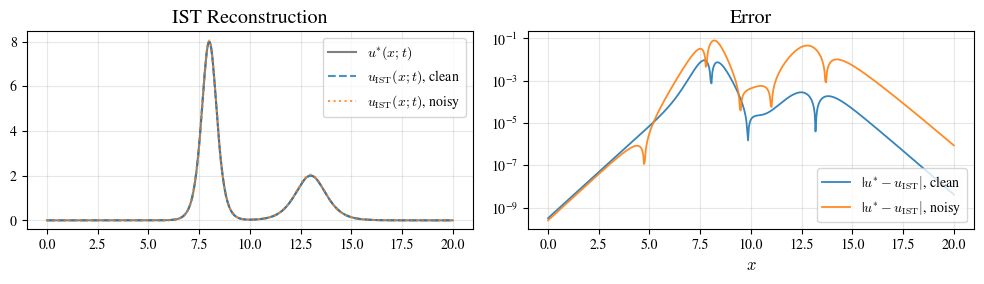

In [9]:
# Reconstruct solution
u_ist = IST_reflectionless(x, kappas, cs)
u_ist_star = IST_reflectionless(x, kappas_star, cs_star)


# Error metrics
err_ist = np.linalg.norm(u_ist - u_star)/np.linalg.norm(u_star)
err_ist_star = np.linalg.norm(u_ist_star - u_star)/np.linalg.norm(u_star)

print(f"Relative L2 error, noisy scattering data: {err_ist:.4e}")
print(f"Relative L2 error, clean scattering data: {err_ist_star:.4e}")

# Plot it!
fig, axes = plt.subplots(1,2, figsize=(10,3), sharex=True)

axes[0].plot(x, u_star, "-", color="grey", lw=1.5, label=r"$u^{*}(x;t)$")
axes[0].plot(x, u_ist_star, "--", color="C0", alpha=0.8, label=r"$u_{\rm IST}(x;t)$, clean")
axes[0].plot(x, u_ist, ":", color="C1", alpha=0.8, label=r"$u_{\rm IST}(x;t)$, noisy")
axes[0].legend(loc="upper right", fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_title(r"IST Reconstruction")

axes[1].plot(x, abs(u_star-u_ist_star), "C0-", lw=1.3, alpha=0.9, label=r"|$u^{*} - u_{\rm IST}|$, clean")
axes[1].plot(x, abs(u_star-u_ist), "C1-", lw=1.3, alpha=0.9, label=r"|$u^{*} - u_{\rm IST}|$, noisy")
axes[1].set_yscale("log")
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel(r"$x$")
axes[1].set_title("Error")

plt.tight_layout()
plt.show()

#### **SOLITON DATA EVOLVING OVER TIME**

In [24]:
# Import KdV collision data
from netCDF4 import Dataset

with Dataset("outputs/kdv_soliton_collision_v0.nc") as nc:
    x = nc["x"][:].data
    t = nc["t"][:].data
    U_star = nc["u"][:].data

# Add noise?
sigma = 0.20
U = U_star + rng.normal(0, sigma, U_star.shape)

# Subsample?
sub_x = 3
x_sub = x[::sub_x]
U_sub = U[:,::sub_x]
U_star_sub = U_star[:,::sub_x]

# Compute scattering data
collision_data = scattering_data_sequence(x_sub, U_sub, t_grid=t, min_kappa=0.25)

print("U shape:", U.shape)
print("sampled U shape:", collision_data.U.shape)
#print("number of bound states:", collision_data.n)

U shape: (200, 1024)
sampled U shape: (200, 342)


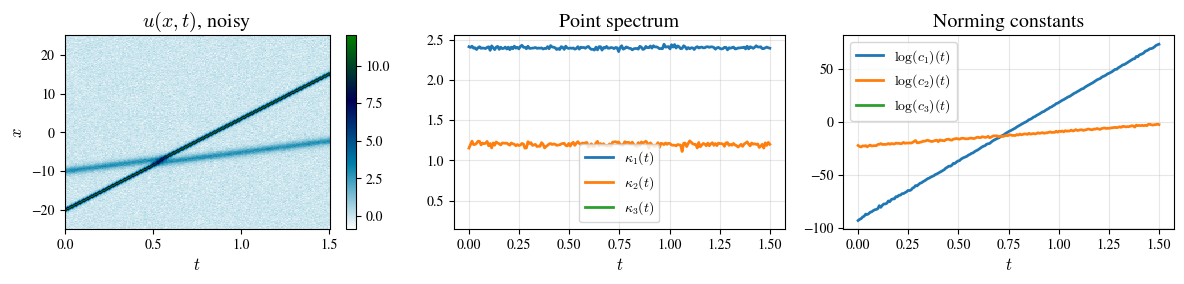

In [25]:
# Plot the time evolution
fig, axes = plt.subplots(1, 3, figsize=(12,3))

pc = axes[0].pcolormesh(t, x, U.T, cmap="ocean_r")#, shading="gouraud")
axes[0].set_title(r"$u(x,t)$, noisy")
axes[0].set_xlabel(r"$t$")
axes[0].set_ylabel(r"$x$")
#axes[0].set_ylim([-18,14])
fig.colorbar(pc, ax=axes[0])

for i in range(max(collision_data.n)):
    ti = []
    ki = []
    logci = []
    for j,sd in enumerate(collision_data.snapshots):
        if len(sd.kappas) > i:
            ti.append(collision_data.t[j])
            ki.append(sd.kappas[i])
            logci.append(sd.log_cs[i])
    axes[1].plot(ti, ki, "-", lw=2, label=rf"$\kappa_{i+1}(t)$")
    axes[2].plot(ti, logci, "-", lw=2, label=rf"$\log(c_{i+1})(t)$")

axes[1].set_title(r"Point spectrum")
axes[1].set_xlabel(r"$t$")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

axes[2].set_title(r"Norming constants")
axes[2].set_xlabel(r"$t$")
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

In [26]:
# Reconstruct the solution
U_ist = np.asarray([IST_reflectionless(x_sub, sd.kappas, sd.cs) for sd in collision_data.snapshots])
err_ist = np.linalg.norm(U_ist - U_star_sub)/np.linalg.norm(U_star_sub)

print(f"Relative L2 error, IST reconstruction: {err_ist:.4e}")

Relative L2 error, IST reconstruction: 9.6338e-02


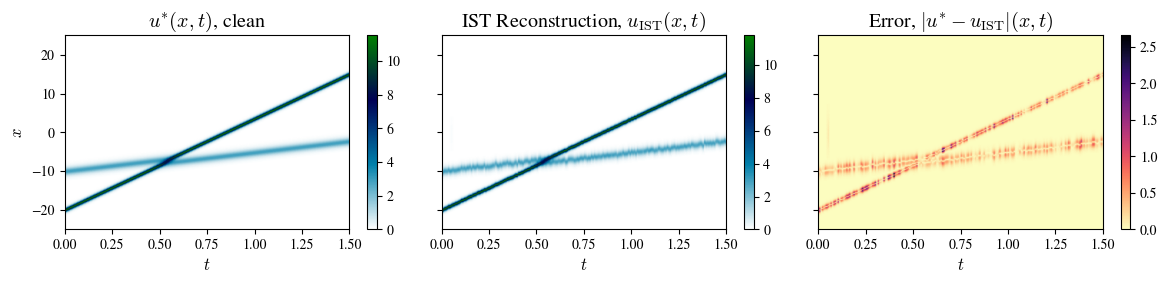

In [27]:
# Plot that sucker
fig, axes = plt.subplots(1, 3, figsize=(12,3), sharex=True, sharey=True)

pc = axes[0].pcolormesh(t, x_sub, U_star_sub.T, cmap="ocean_r", shading="gouraud")
#pc = axes[0].pcolormesh(t, x_sub, U_sub.T, cmap="ocean_r")
axes[0].set_title(r"$u^{*}(x,t)$, clean")
#axes[0].set_title(r"$u(x,t)$, noisy")
axes[0].set_xlabel(r"$t$")
axes[0].set_ylabel(r"$x$")
#axes[0].set_ylim([-18,14])
fig.colorbar(pc, ax=axes[0])

pc = axes[1].pcolormesh(t, x_sub, U_ist.T, cmap="ocean_r", shading="gouraud")
axes[1].set_title(r"IST Reconstruction, $u_{\rm IST}(x,t)$")
axes[1].set_xlabel(r"$t$")
fig.colorbar(pc, ax=axes[1])

pc = axes[2].pcolormesh(t, x_sub, abs(U_star_sub - U_ist).T, cmap="magma_r", shading="gouraud")
axes[2].set_title(r"Error, $|u^{*} - u_{\rm IST}|(x,t)$")
axes[2].set_xlabel(r"$t$")
fig.colorbar(pc, ax=axes[2])

plt.tight_layout()
plt.show()